# Temporal-based predictive analysis
This notebook reproduce the results related to temporal-based approaches used in the article. 

These models are:  
- Gated Recurrent Units (GRU)

In [1]:
import sys
sys.path.append("../.")
import os
import numpy as np
import torch

from OpenDeckGeneration.data_cv import create_kfold_splits
from OpenDeckGeneration.evaluator import evaluate_predictions, extract_metrics_for_table

from package.data import Data
from package.plots.plots import plot_cv_losses, plot_obs_vs_pred

from package.model import RecurrentTrainer
from package.model.architecture.gru import GRUSeq2Seq
from package.model.recurrent_trainer import masked_mse

In [2]:
file_name = "2000_aligned_and_clean_indexfalse.csv"
file_path = os.path.join("..", "data", file_name)

data = Data()
data.load(load_path=file_path)

Herein, we train and evaluate through 5 folds cross validation a GRU model to learn the health indicators from sensor measurements by considering the data as time series.

In [ ]:
predictions_all = []
observations_all = []
train_losses = []
val_losses = []
metrics = {}
input_indices = [*list(range(14,21)), *list(range(27,34)), *list(range(40,47)), *list(range(53,60))]
output_indices = list(range(0,10))

for train_idx, val_idx, test_idx in create_kfold_splits(n_sequences=len(data.sequences),
                                                        k_folds=5,
                                                        train_ratio=0.7,
                                                        val_ratio=0.1,
                                                        test_ratio=0.2):
    train_loader, val_loader, test_loader, scaler_input, scaler_output = data.create_dataloaders_series(train_idx,
                                                                                   val_idx,
                                                                                   test_idx,
                                                                                   input_indices=input_indices,
                                                                                   output_indices=output_indices,
                                                                                   batch_size=10
                                                                                   )
    model = GRUSeq2Seq(input_size=28,
                       hidden_size=128,
                       num_layers=2,
                       output_size=10,
                       bidirectional=False,
                       dropout=0,
                       device="cuda:0")

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',        # because we monitor validation loss
        factor=0.5,        # reduce LR by half
        patience=3,        # wait 3 epochs before reducing
    )

    trainer = RecurrentTrainer(
        model,
        masked_loss=masked_mse,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler_output
    )
    trainer.train_model(train_loader=train_loader, epochs=50, val_loader=val_loader)
    train_losses.append(trainer.train_losses)
    val_losses.append(trainer.val_losses)
    observations, predictions = trainer.predict_loader(test_loader)
    predictions_all.append(predictions)
    observations_all.append(observations)
    evaluate_predictions(y_true=np.vstack(observations), y_pred=np.vstack(predictions), metrics=metrics)

Visualizing the convergence behavior of the model

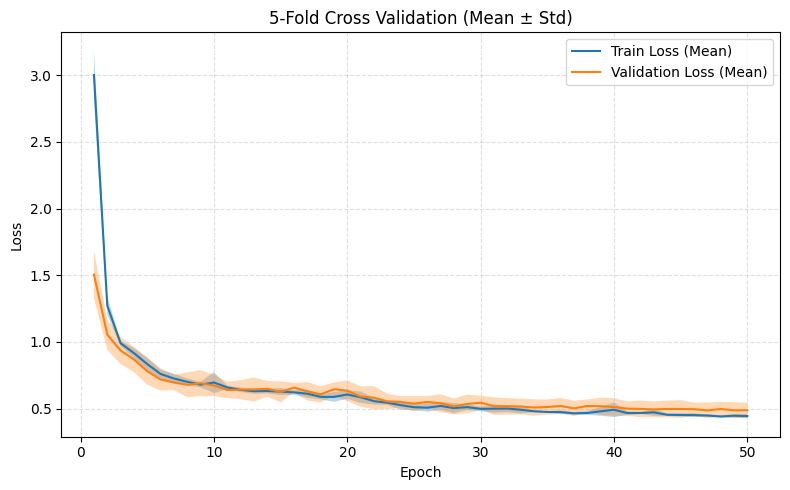

In [4]:
train_losses = [np.array(train_loss) for train_loss in train_losses]
val_losses = [np.array(val_loss) for val_loss in val_losses]

plot_cv_losses(training_losses=train_losses, validation_losses=val_losses)

Showing the performance measures

In [5]:
extract_metrics_for_table(metrics)

{'SAPE': {'deg_CmpBst_s_mapEff_in': '0.1207 $\\pm$ 0.2234',
  'deg_CmpBst_s_mapWc_in': '0.0933 $\\pm$ 0.2121',
  'deg_CmpFan_s_mapEff_in': '0.2744 $\\pm$ 0.2477',
  'deg_CmpFan_s_mapWc_in': '0.0399 $\\pm$ 0.1368',
  'deg_CmpH_s_mapEff_in': '0.0496 $\\pm$ 0.1624',
  'deg_CmpH_s_mapWc_in': '0.0772 $\\pm$ 0.2047',
  'deg_TrbH_s_mapEff_in': '0.1602 $\\pm$ 0.2036',
  'deg_TrbH_s_mapWc_in': '0.0622 $\\pm$ 0.1751',
  'deg_TrbL_s_mapEff_in': '0.2154 $\\pm$ 0.2272',
  'deg_TrbL_s_mapWc_in': '0.2856 $\\pm$ 0.2699'},
 'rmse_per_var': {'deg_CmpBst_s_mapEff_in': '0.0006 $\\pm$ 0.0000',
  'deg_CmpBst_s_mapWc_in': '0.0005 $\\pm$ 0.0000',
  'deg_CmpFan_s_mapEff_in': '0.0021 $\\pm$ 0.0001',
  'deg_CmpFan_s_mapWc_in': '0.0002 $\\pm$ 0.0000',
  'deg_CmpH_s_mapEff_in': '0.0004 $\\pm$ 0.0000',
  'deg_CmpH_s_mapWc_in': '0.0007 $\\pm$ 0.0001',
  'deg_TrbH_s_mapEff_in': '0.0011 $\\pm$ 0.0001',
  'deg_TrbH_s_mapWc_in': '0.0003 $\\pm$ 0.0000',
  'deg_TrbL_s_mapEff_in': '0.0016 $\\pm$ 0.0000',
  'deg_TrbL_s_mapW

Visualizing the a health indicator prediction example for this model

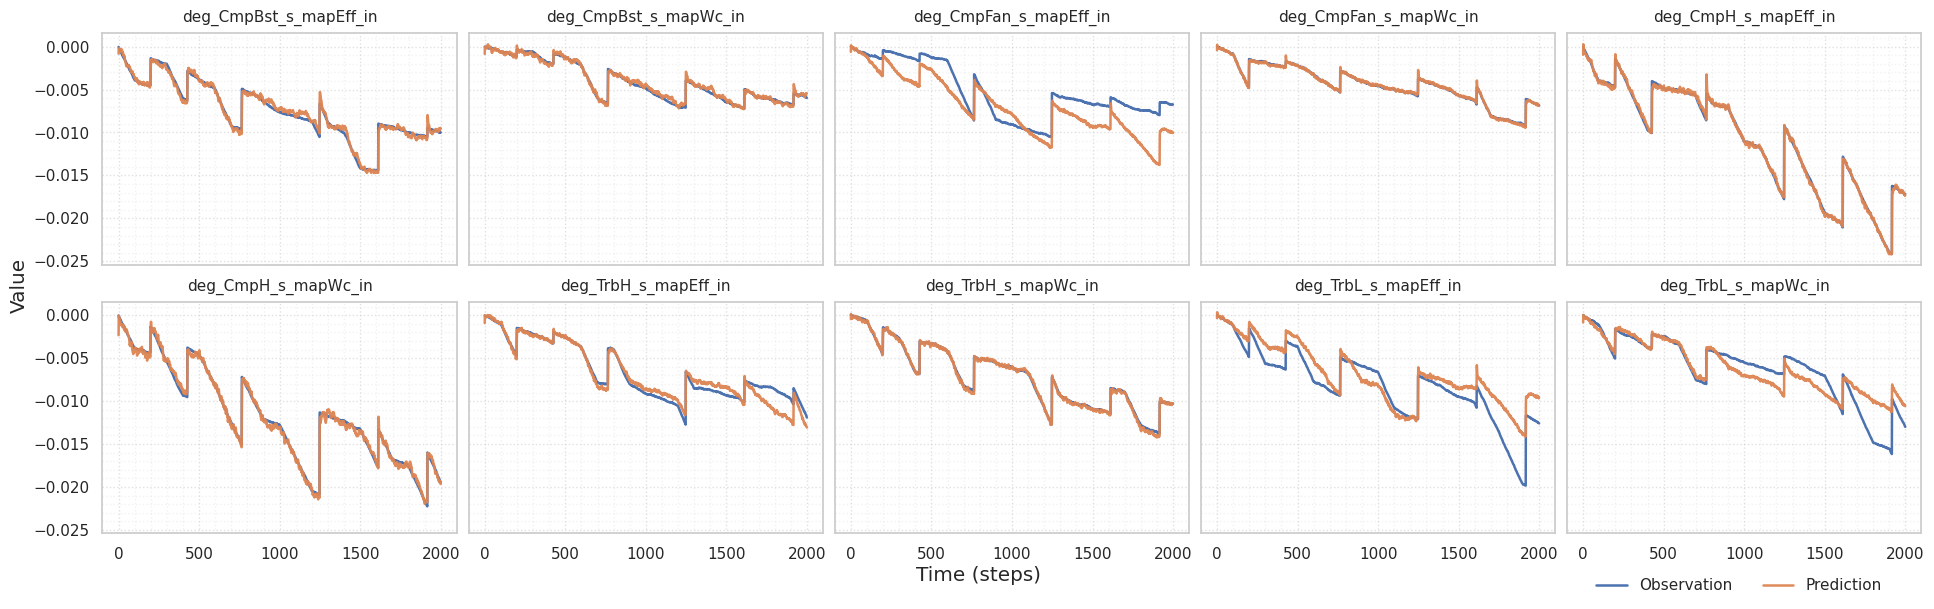

(<Figure size 1900x560 with 10 Axes>,
 array([[<Axes: title={'center': 'deg_CmpBst_s_mapEff_in'}>,
         <Axes: title={'center': 'deg_CmpBst_s_mapWc_in'}>,
         <Axes: title={'center': 'deg_CmpFan_s_mapEff_in'}>,
         <Axes: title={'center': 'deg_CmpFan_s_mapWc_in'}>,
         <Axes: title={'center': 'deg_CmpH_s_mapEff_in'}>],
        [<Axes: title={'center': 'deg_CmpH_s_mapWc_in'}>,
         <Axes: title={'center': 'deg_TrbH_s_mapEff_in'}>,
         <Axes: title={'center': 'deg_TrbH_s_mapWc_in'}>,
         <Axes: title={'center': 'deg_TrbL_s_mapEff_in'}>,
         <Axes: title={'center': 'deg_TrbL_s_mapWc_in'}>]], dtype=object))

In [6]:
OUTPUT_FEATURES = ['deg_CmpBst_s_mapEff_in', 'deg_CmpBst_s_mapWc_in', 'deg_CmpFan_s_mapEff_in', 
                   'deg_CmpFan_s_mapWc_in', 'deg_CmpH_s_mapEff_in', 'deg_CmpH_s_mapWc_in', 
                   'deg_TrbH_s_mapEff_in', 'deg_TrbH_s_mapWc_in', 'deg_TrbL_s_mapEff_in', 
                   'deg_TrbL_s_mapWc_in']

plot_obs_vs_pred(observations[0], predictions[0],
    variable_names=OUTPUT_FEATURES,     # or None
    layout="2x5",             # or "5x2"
    style="whitegrid",        # "whitegrid" is a nice default
    palette=("C0", "C1"),     # pick your favorite colors (e.g., "#1f77b4", "#ff7f0e")
    x_label="Time (steps)",
    y_label="Value",
    legend_loc="bottom",      # safest to avoid overlaps
    show=True
)